In [1]:
import pandas as pd
import numpy as np
import os, glob
import re
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [2]:
full=False
if full:
    remove_list = ['dft']
else:
    remove_list = ['dft', '7net-0', '7net-l3i5', '7net-omat']

In [22]:
df = pd.read_csv('/Users/yujinkang/febench/all/all.csv')

df

,model,DFT,ompa-mpa,ompa-omat,MACE-mpa,MACE-omat,ORB-mpa,ORB-omat,eSEN-oam,eSEN-omat,DPA-mp,DPA-omat,UMA-omc,UMA-omat,omni-mpa,omni-omat,omni-matpes_pbe
0,C_a1,0.470,0.704224,0.725830,0.401811,0.946671,0.603394,0.591064,0.523682,0.528076,0.599515,0.759837,-3.327481,0.658051,0.602661,0.747559,0.749512
1,C_a2,-0.010,0.149780,0.176514,-0.040902,0.211581,-0.079468,-0.030273,-0.021484,NaN,0.060142,0.103535,0.036560,0.049103,0.011597,0.085449,0.093018
2,C_b1,0.680,1.305420,1.343750,0.843394,1.596747,1.080322,1.158447,1.068848,1.078003,0.958472,1.234555,-0.951723,1.184586,1.050903,1.310303,1.348267
3,C_b2,0.470,0.487915,0.529297,0.248817,0.956098,0.296753,0.306030,0.500366,0.501221,0.490735,0.554143,-0.047834,0.549438,0.323242,0.434448,0.440552
4,C_b3,0.340,0.912598,0.935791,0.494987,1.166349,0.767456,0.761841,0.761230,0.754639,0.742437,0.893138,-0.918471,0.789307,0.798584,0.936523,0.941284
5,C_c1,0.580,1.065186,1.098145,0.660470,1.284659,0.766846,0.781982,0.754639,0.762329,0.865548,1.082922,4.393798,NaN,0.888428,1.048584,1.111450
6,C_c2,0.120,0.622070,0.665039,0.177607,0.953133,0.286377,0.315430,0.358887,0.362183,0.865549,0.724986,4.393797,0.515427,0.465576,0.642944,0.674438
7,C_d,0.160,0.090088,0.092651,0.102144,0.102549,0.087402,0.110718,0.042725,NaN,0.077767,0.104160,3.955577,0.109238,0.044434,0.073730,0.064575
8,C_e,0.130,0.092285,0.110107,0.158897,0.126573,0.043457,0.070435,-0.001587,0.001709,0.078711,0.130926,3.132078,0.071487,-0.019775,0.041504,0.047363
9,C_f,-0.090,-0.042969,-0.004761,0.015525,-0.120993,-0.030518,0.024170,-0.125610,-0.144653,-0.044352,0.032939,8.830279,NaN,-0.151001,-0.048096,-0.043457


In [23]:
# df.drop(columns=['solute'], inplace=True)
mlip_list = df.columns.tolist()
remove_list = ['DFT','model']
for r in remove_list:
    mlip_list.remove(r)

delta_df = pd.DataFrame()
print(delta_df)
# delta_df['config'] = df['model']    
for mlip in mlip_list:
    df[mlip+'_delta'] = df[mlip] - df['DFT']
    delta_df[mlip] = df[mlip]-df['DFT']
delta_df.to_csv('/Users/yujinkang/delta_E_bind.csv', index=False)
# df.reset_index(inplace=True)
delta_df

Empty DataFrame
Columns: []
Index: []


,ompa-mpa,ompa-omat,MACE-mpa,MACE-omat,ORB-mpa,ORB-omat,eSEN-oam,eSEN-omat,DPA-mp,DPA-omat,UMA-omc,UMA-omat,omni-mpa,omni-omat,omni-matpes_pbe
0,0.234224,0.255830,-0.068189,0.476671,0.133394,0.121064,0.053682,0.058076,0.129515,0.289837,-3.797481,0.188051,0.132661,0.277559,0.279512
1,0.159780,0.186514,-0.030902,0.221581,-0.069468,-0.020273,-0.011484,NaN,0.070142,0.113535,0.046560,0.059103,0.021597,0.095449,0.103018
2,0.625420,0.663750,0.163394,0.916747,0.400322,0.478447,0.388848,0.398003,0.278472,0.554555,-1.631722,0.504586,0.370903,0.630303,0.668267
3,0.017915,0.059297,-0.221183,0.486098,-0.173247,-0.163970,0.030366,0.031221,0.020735,0.084143,-0.517834,0.079438,-0.146758,-0.035552,-0.029448
4,0.572598,0.595791,0.154987,0.826349,0.427456,0.421841,0.421230,0.414639,0.402437,0.553138,-1.258471,0.449307,0.458584,0.596523,0.601284
5,0.485186,0.518145,0.080470,0.704659,0.186846,0.201982,0.174639,0.182329,0.285548,0.502922,3.813798,NaN,0.308428,0.468584,0.531450
6,0.502070,0.545039,0.057607,0.833133,0.166377,0.195430,0.238887,0.242183,0.745549,0.604986,4.273797,0.395427,0.345576,0.522944,0.554438
7,-0.069912,-0.067349,-0.057856,-0.057451,-0.072598,-0.049282,-0.117275,NaN,-0.082233,-0.055840,3.795577,-0.050762,-0.115566,-0.086270,-0.095425
8,-0.037715,-0.019893,0.028897,-0.003427,-0.086543,-0.059565,-0.131587,-0.128291,-0.051289,0.000926,3.002078,-0.058513,-0.149775,-0.088496,-0.082637
9,0.047031,0.085239,0.105525,-0.030993,0.059482,0.114170,-0.035610,-0.054653,0.045648,0.122939,8.920279,NaN,-0.061001,0.041904,0.046543


In [43]:
error_df = pd.DataFrame()
for mlip in mlip_list:
    error_df.loc['MAE',mlip] = abs_df[mlip].mean()
error_df.to_csv('/Users/yujinkang/mae_E_bind.csv')

In [33]:
abs_err = df[mlip_list].sub(df['DFT'], axis=0).abs()
abs_err
mae = abs_err.mean()
mae
n_used = abs_err.count()
n_used
coverage = (n_used / len(df)).rename("coverage")
summary = pd.concat([mae.rename("MAE"), n_used.rename("N_used"), coverage], axis=1).sort_values("MAE")
summary.to_csv('/Users/yujinkang/summary_E_bind.csv')

In [25]:
abs_df = delta_df.abs()
abs_df.to_csv('/Users/yujinkang/abs_delta_E_bind.csv', index=False)

In [13]:
sns_df = pd.DataFrame(columns=['index','DFT', 'mlip', 'pred','delta','abs_error'], index=range(len(mlip_list)*len(df)))
idx = 0
for i in range(len(df)):
    for mlip in mlip_list:
        sns_df.loc[idx, 'index'] = i
        sns_df.loc[idx, 'DFT'] = df.loc[i, 'DFT']
        sns_df.loc[idx, 'mlip'] =  mlip
        sns_df.loc[idx, 'pred'] = df.loc[i, mlip]
        sns_df.loc[idx, 'delta'] = df.loc[i, mlip+'_delta']
        sns_df.loc[idx, 'abs_error'] = abs(df.loc[i, mlip+'_delta'])
        idx += 1
sns_df.to_csv('/Users/yujinkang/sns.csv', index=False)

In [89]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 5

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.18
plt.rcParams['figure.subplot.left'] = 0.1
plt.rcParams['figure.subplot.right'] = 0.97
plt.rcParams['figure.subplot.top'] = 0.98
plt.rcParams['figure.subplot.wspace'] = 0.03
plt.rcParams['figure.subplot.hspace'] = 0.03



In [18]:

color_dict= {
    'ompa-omat': '#02baae',
    'ompa-mpa': '#72b8b3',
    'omni-omat': '#0073ff',
    'omni-mpa': '#8cbbf5',
    'omni-matpes_pbe': '#0047b3',
    'ORB-omat': '#d48f3f',
    'ORB-mpa': '#d9ba98',
    'eSEN-omat':'#e8d803',
    'eSEN-oam': '#f5ea74',
    'DPA-mp': '#d19adf',
    'DPA-omat': '#e829f6',
    'UMA-omat': '#ff0000',
    'UMA-omc': '#ff7f7f',
    'MACE-omat': '#00b300',
    'MACE-mpa': '#66ff66',
}


In [30]:
carbon_df = pd.read_csv('../carbon/mae_E_bind.csv',index_col=0)
tm_df = pd.read_csv('../tm/mae_E_bind.csv',index_col=0)
tot_df = pd.read_csv('../tot/mae_E_bind.csv', index_col=0)

In [31]:

carbon_mae = carbon_df.loc['MAE'].values
tm_mae = tm_df.loc['MAE'].values
tot_mae = tot_df.loc['MAE'].values
carbon = pd.DataFrame()
carbon['mlip'] = carbon_df.keys().tolist()
tm = pd.DataFrame()
tm['mlip'] = tm_df.keys().tolist()
tot = pd.DataFrame()
tot['mlip'] = tot_df.keys().tolist()
carbon['MAE'] = carbon_mae
tm['MAE'] = tm_mae
tot['MAE'] = tot_mae
 
carbon.to_csv('../carbon/sns_mae.csv', index=False)
tm.to_csv('../tm/sns_mae.csv', index=False)
tot.to_csv('../tot/sns_mae.csv', index=False)

In [35]:
carbon = pd.read_csv('../carbon/sns_mae.csv')
tm = pd.read_csv('../tm/sns_mae.csv')
tot = pd.read_csv('../tot/sns_mae.csv')
carbon =carbon.drop(carbon[carbon['mlip']=='UMA-omc'].index)
tm =tm.drop(tm[tm['mlip']=='UMA-omc'].index)
tot =tot.drop(tot[tot['mlip']=='UMA-omc'].index)

/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_2671/3152433510.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


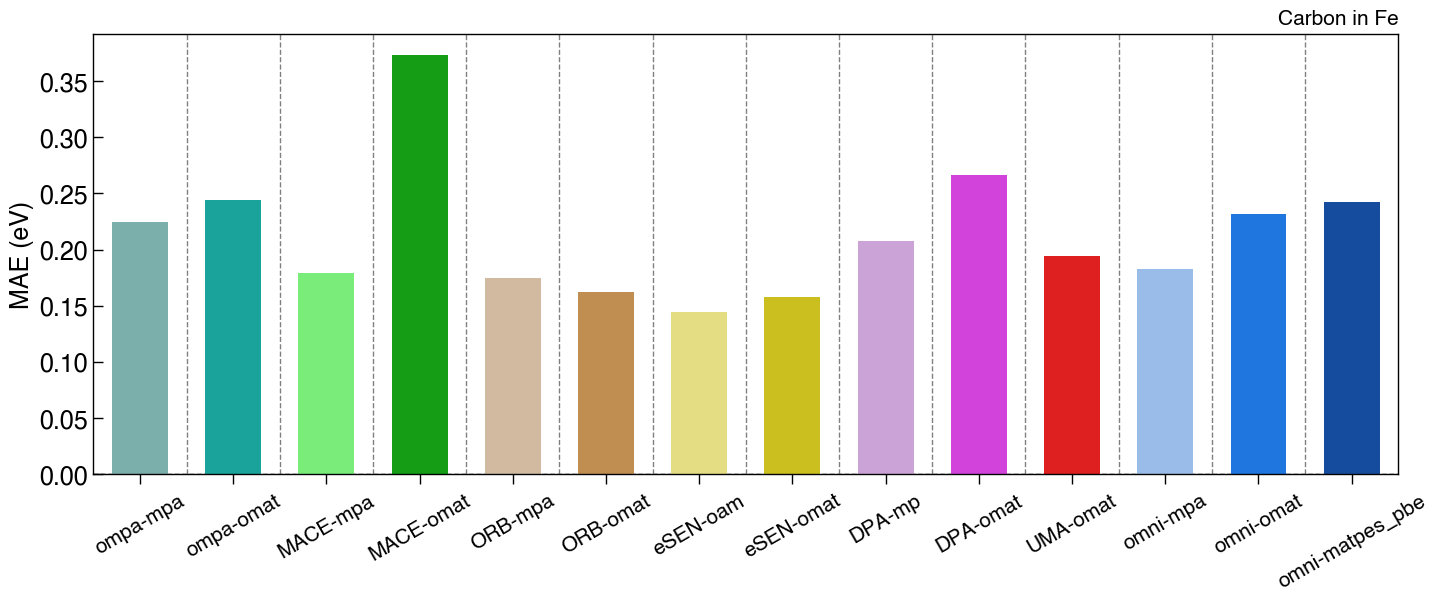

In [49]:
plt.figure(figsize=(15,5.5))
vlines = [i+0.5 for i in range(len(carbon)-1)]
mlip_list = carbon['mlip']
sns.barplot(
    data=carbon, 
    x="mlip", 
    y="MAE", 
    width = 0.6,
    palette=color_dict,   # pick any color scheme
    errorbar=None        # removes those ugly error bars
)
plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
plt.title(r"Carbon in Fe")
plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
for v in vlines:
    plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
plt.ylabel(r"MAE (eV)")
plt.xlabel("")

plt.tick_params(axis="x", which="major", pad=5)
filename = 'fig_mae_carbon.png'
plt.savefig(filename, transparent=True)

plt.show()


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_2671/2095975151.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


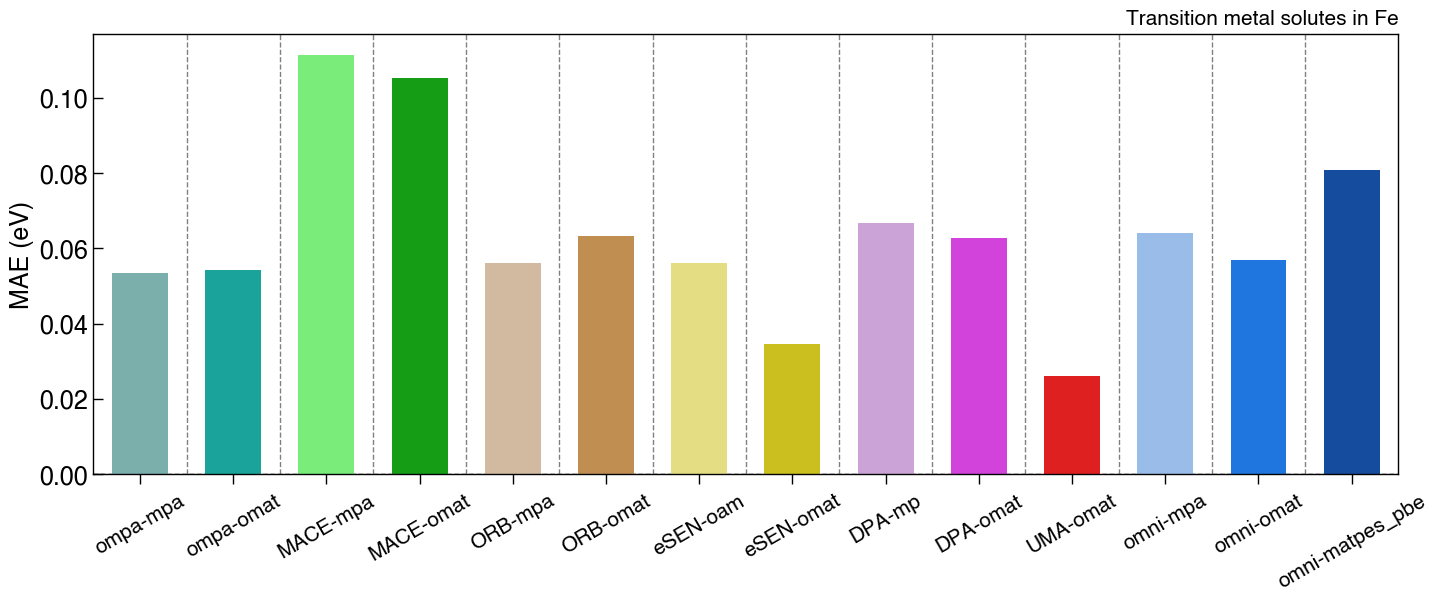

In [54]:
plt.figure(figsize=(15,5.5))
vlines = [i+0.5 for i in range(len(tm)-1)]
mlip_list = tm['mlip']
sns.barplot(
    data=tm, 
    x="mlip", 
    y="MAE", 
    width = 0.6,
    palette=color_dict,   # pick any color scheme
    errorbar=None        # removes those ugly error bars
)
plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
plt.title(r"Transition metal solutes in Fe")
plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
for v in vlines:
    plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
plt.ylabel(r"MAE (eV)")
plt.xlabel("")

plt.tick_params(axis="x", which="major", pad=5)
filename = 'fig_mae_tm.png'
plt.savefig(filename, transparent=True)

plt.show()


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_2671/1192494557.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


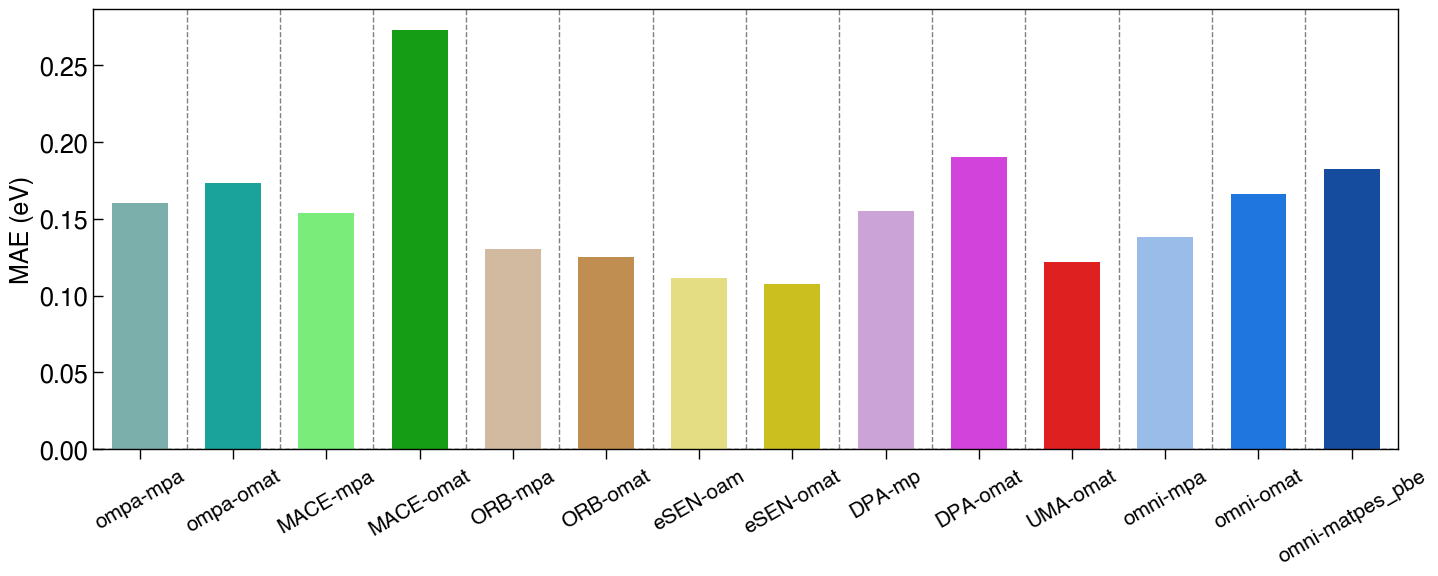

In [55]:
plt.figure(figsize=(15,5.5))
vlines = [i+0.5 for i in range(len(tm)-1)]
mlip_list = tot['mlip']
sns.barplot(
    data=tot, 
    x="mlip", 
    y="MAE", 
    width = 0.6,
    palette=color_dict,   # pick any color scheme
    errorbar=None        # removes those ugly error bars
)
plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
# plt.title(r"Carbon in Fe")
plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
for v in vlines:
    plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
plt.ylabel(r"MAE (eV)")
plt.xlabel("")

plt.tick_params(axis="x", which="major", pad=5)
filename = 'fig_mae_tot.png'
plt.savefig(filename, transparent=True)

plt.show()


In [44]:
def plot_box(sns_df,filename):
    plt.figure(figsize=(15,6.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]
    sns.boxplot(
        data=sns_df,
        x="mlip",
        y="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.6
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
        
    plt.tick_params(axis="x", which="major", pad=5)
    plt.savefig(filename, transparent=True)
    # plt.close()
    plt.show()
    print(f'Box plot saved as {filename}')


In [52]:
def plot_violin(sns_df, filename):
    plt.figure(figsize=(15,5.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]

    sns.violinplot(
        data=sns_df,
        x="mlip",
        y="delta",          
        inner="quartile",
        cut=0,
        palette=color_dict
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=30)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
    
    # sns.despine()
    
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tight_layout()
    plt.savefig(filename, transparent=True)
    plt.show()

    print(f'Violin plot saved as {filename}')


In [107]:
df = pd.read_csv('/Users/jinvk/febench/tm/tm.csv', index_col=0)
# df = df.drop(columns=['UMA-omc'])

In [42]:
solutes = df.keys().tolist()
mlip_list = df.columns.tolist()[1:]

In [114]:
df.loc['Co']['DFT']

-0.043

In [43]:
len(mlip_list)

15

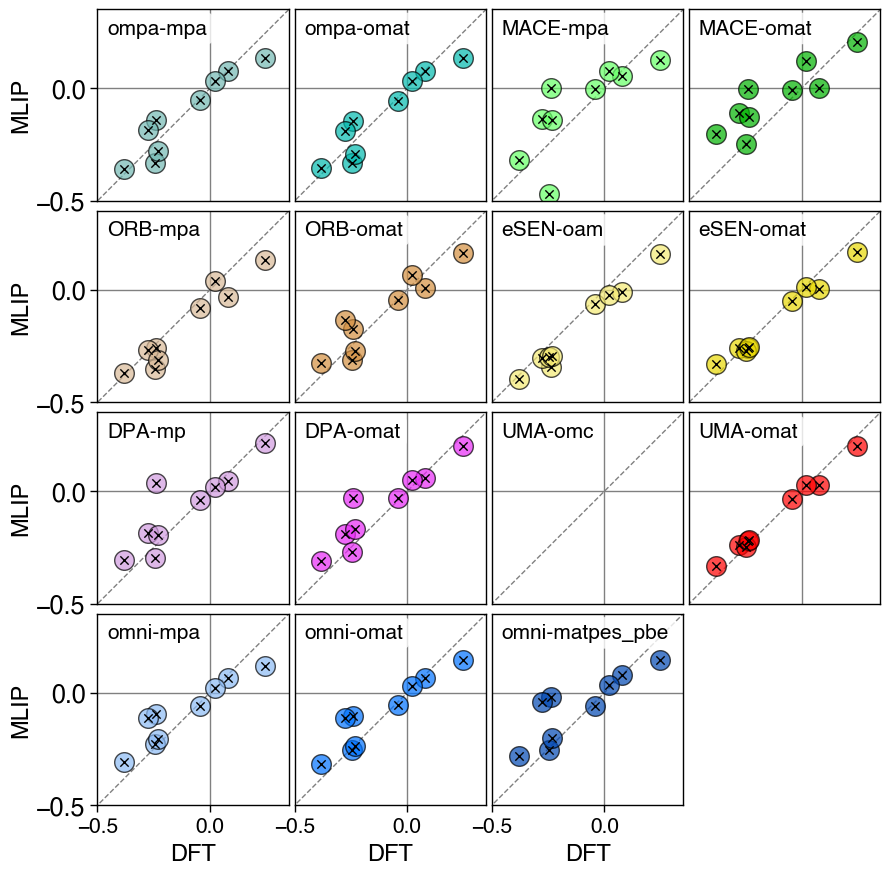

In [200]:
lims = [-0.5, 0.35]
fig, axes = plt.subplots(4,4, figsize=(9,10), sharex=True, sharey=True)
for i, (ax, mlip) in enumerate(zip(axes.flatten(), mlip_list)):
    if i < len(mlip_list):
        ax.plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
        ax.scatter(df['DFT'], df[mlip], color='k', marker='x', alpha=1, zorder=2)        
        ax.scatter(df['DFT'], df[mlip], color=color_dict[mlip], s=200, edgecolors='k', linewidth=1, alpha=0.7)
        ax.axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
        ax.axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
        # ax.set_title(mlip)
        ax.set_box_aspect(1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.text(0.05, 0.95, mlip, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
        if i % 4 == 0:
            ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
        else:
            ax.get_yaxis().set_visible(False)
        if i < 12:
            ax.get_xaxis().set_visible(False)
        else:
            ax.set_xlabel("DFT", fontsize=17, labelpad=5)


        
        # ax.set_xticks(rotation=90)
        # ax.set_ylabel("MLIP")
        # ax.set_xlabel('DFT')
    else:
        # continue
        ax.axis('off')
for ax in axes.flatten()[len(mlip_list):]:
    ax.axis("off")
# fig.tight_layout()

plt.savefig('tm_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [201]:
solute_color_dict = {
    'Co': '#95bcff',
    'Cr': '#efa366',
    'Cu': '#03bc25',
    'Mn': '#ffa9ec',
    'Mo': '#b1ffba',
    'Nb': '#adadad',
    'Ni': '#e2e2e2',
    'Ti': '#00d4df',
    'V': '#fee900',
}
df = pd.read_csv('/Users/jinvk/febench/tm/tm.csv', index_col=0)
# df = df.drop(columns=['UMA-omc'])
solutes = df.index.tolist()
mlip_list = df.columns.tolist()[1:]
df['DFT']
print(mlip_list)
len(df['ompa-omat'])

['ompa-mpa', 'ompa-omat', 'MACE-mpa', 'MACE-omat', 'ORB-mpa', 'ORB-omat', 'eSEN-oam', 'eSEN-omat', 'DPA-mp', 'DPA-omat', 'UMA-omc', 'UMA-omat', 'omni-mpa', 'omni-omat', 'omni-matpes_pbe']


9

In [139]:
df.index

Index(['Co', 'Cr', 'Cu', 'Mn', 'Mo', 'Nb', 'Ni', 'Ti', 'V'], dtype='object')

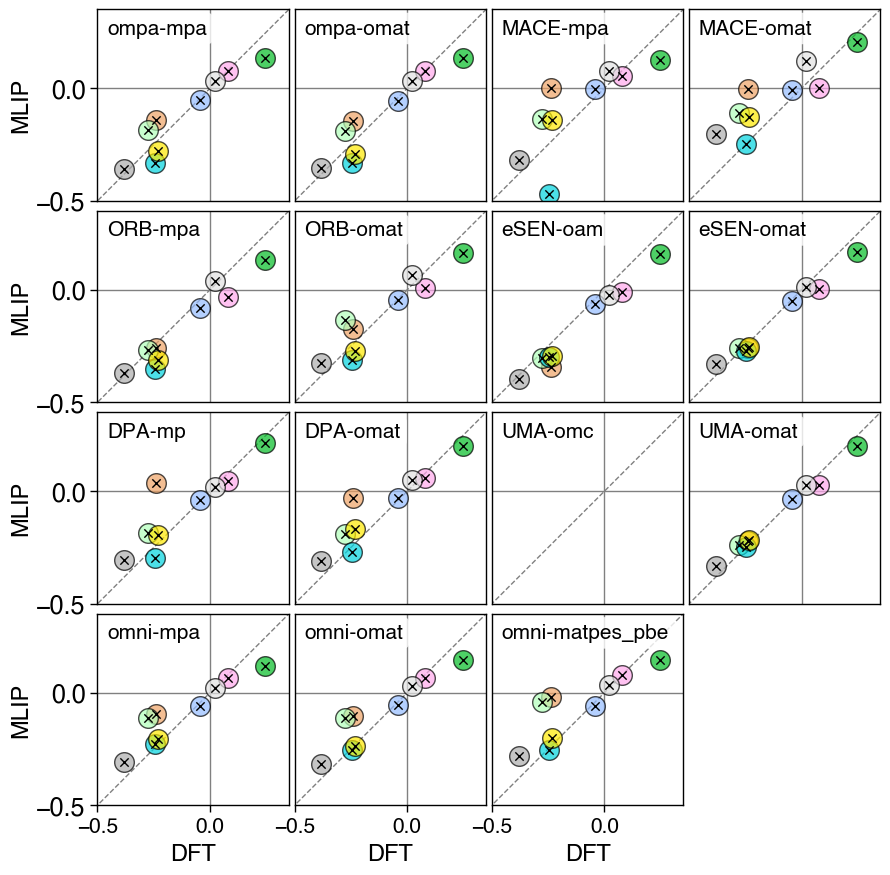

In [202]:
lims = [-0.5, 0.35]
fig, axes = plt.subplots(4,4, figsize=(9,10), sharex=True, sharey=True)
dft = df['DFT'].tolist()
for i, (ax, mlip) in enumerate(zip(axes.flatten(), mlip_list)):
    mlip_values = df[mlip].tolist()
    ax.axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    ax.plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    # ax.set_title(mlip)
    ax.set_box_aspect(1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.text(0.05, 0.95, mlip, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    for j, solute in enumerate(solutes):
        ax.scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=2)        
        ax.scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=200, edgecolors='k', linewidth=1, alpha=0.7)
    
    if i % 4 == 0:
        ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
    else:
        ax.get_yaxis().set_visible(False)
    if i < 12:
        ax.get_xaxis().set_visible(False)
    else:
        ax.set_xlabel("DFT", fontsize=17, labelpad=5)
            
for ax in axes.flatten()[len(mlip_list):]:
    ax.axis("off")
# fig.tight_layout()

plt.savefig('tm_el_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


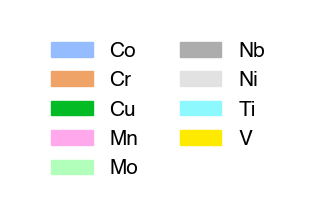

In [157]:
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color, label=solute) for solute, color in solute_color_dict.items()]
fig, ax = plt.subplots()
ax.axis('off')
legend = ax.legend(handles=handles, loc='center', ncol=2, frameon=False, fontsize=15)

In [168]:
import matplotlib.markers as mmarkers
import matplotlib.path as mpath

def circle_x_marker():
    # start with a circle
    circle = mpath.Path.unit_circle()
    # cross lines
    verts = [
        (-0.7, -0.7), (0.7, 0.7), (np.nan, np.nan),
        (-0.7, 0.7), (0.7, -0.7)
    ]
    cross = mpath.Path(verts)
    return mpath.Path.make_compound_path(circle, cross)

circle_x = mmarkers.MarkerStyle(circle_x_marker())

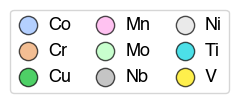

In [203]:
fig, ax = plt.subplots(figsize=(2,1.2))
for j, solute in enumerate(solutes):
    ax.scatter(1,1, color = solute_color_dict[solute], s=120, edgecolors='k', linewidth=1, alpha=0.7, label=solute)
    ax.scatter(1,1, color='k', marker='x', alpha=1, zorder=2)
ax.axis('off')
ax.set_xlim(0,0.1)
ax.set_ylim(0,0.1)
ax.legend(loc='center', ncol=3, frameon=True, fontsize='medium', markerscale=1.2, borderpad = 0.4, labelspacing=0.5, handlelength=1.2, handletextpad=0.5, columnspacing=1.3,)
fig.tight_layout()
fig.savefig('tm_legend.png', dpi=300, bbox_inches='tight', transparent=True)

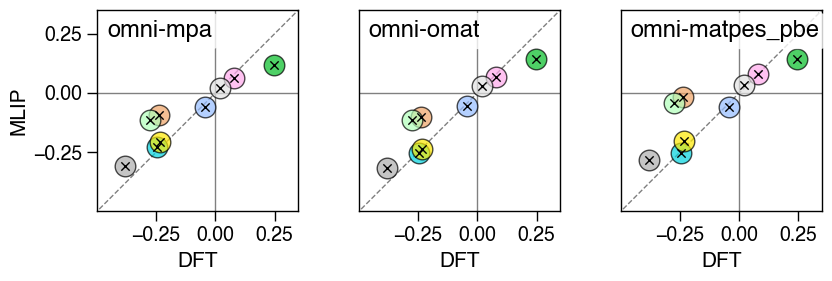

In [222]:
fig, ax = plt.subplots(1,3 , figsize=(9,3), sharey=True)
ax = ax.flatten()
dft = df['DFT'].tolist()
mlips = ['omni-mpa', 'omni-omat', 'omni-matpes_pbe']
lims = [-0.5, 0.35]
plt.rcParams['xtick.major.size'] = 7
ticks = [-0.25, 0, 0.25]
plt.rcParams['ytick.major.size'] = 7

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
for i, mlip in enumerate(mlips):
    mlip_values = df[mlip].tolist()
    ax[i].axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    ax[i].plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax[i].axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    # ax.set_title(mlip)
    ax[i].set_box_aspect(1)
    ax[i].set_xlim(lims)
    ax[i].set_ylim(lims)
    ax[i].set_xticks(ticks)
    ax[i].set_yticks(ticks)
    ax[i].text(0.05, 0.95, mlip, transform=ax[i].transAxes, fontsize=17, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    for j, solute in enumerate(solutes):
        ax[i].scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=2)        
        ax[i].scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=220, edgecolors='k', linewidth=1, alpha=0.7)
    
    if i == 0:
        ax[i].set_ylabel("MLIP", fontsize=15, labelpad=3)
    else:
        ax[i].get_yaxis().set_visible(False)

    ax[i].set_xlabel("DFT", fontsize=15, labelpad=5)
fig.tight_layout()
plt.savefig('omni.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


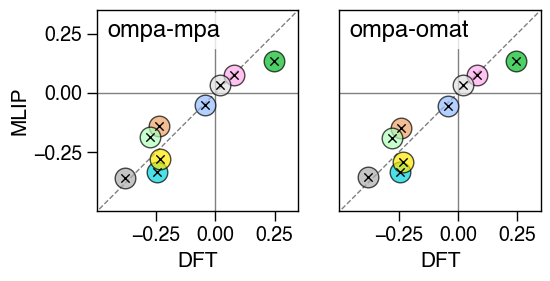

In [223]:
fig, ax = plt.subplots(1,2 , figsize=(6,3), sharey=True)
ax = ax.flatten()
dft = df['DFT'].tolist()
mlips = ['ompa-mpa', 'ompa-omat']
lims = [-0.5, 0.35]
plt.rcParams['xtick.major.size'] = 7
ticks = [-0.25, 0, 0.25]
plt.rcParams['ytick.major.size'] = 7

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
for i, mlip in enumerate(mlips):
    mlip_values = df[mlip].tolist()
    ax[i].axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    ax[i].plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax[i].axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    # ax.set_title(mlip)
    ax[i].set_box_aspect(1)
    ax[i].set_xlim(lims)
    ax[i].set_ylim(lims)
    ax[i].set_xticks(ticks)
    ax[i].set_yticks(ticks)
    ax[i].text(0.05, 0.95, mlip, transform=ax[i].transAxes, fontsize=17, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    for j, solute in enumerate(solutes):
        ax[i].scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=2)        
        ax[i].scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=220, edgecolors='k', linewidth=1, alpha=0.7)
    
    if i == 0:
        ax[i].set_ylabel("MLIP", fontsize=15, labelpad=3)
    else:
        ax[i].get_yaxis().set_visible(False)

    ax[i].set_xlabel("DFT", fontsize=15, labelpad=5)
fig.tight_layout()
plt.savefig('ompa.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


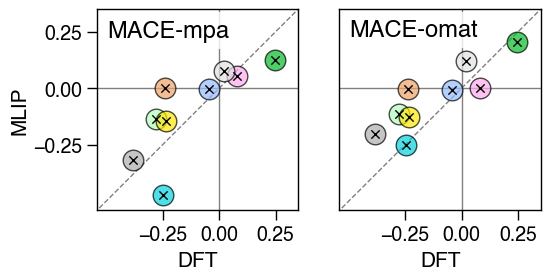

In [228]:

fig, ax = plt.subplots(1,2 , figsize=(6,3), sharey=True)
ax = ax.flatten()
dft = df['DFT'].tolist()
mlips = ['MACE-mpa', 'MACE-omat']
lims = [-0.54, 0.35]
plt.rcParams['xtick.major.size'] = 7
ticks = [-0.25, 0, 0.25]
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

for i, mlip in enumerate(mlips):
    mlip_values = df[mlip].tolist()
    ax[i].axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    ax[i].plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax[i].axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    # ax.set_title(mlip)
    ax[i].set_box_aspect(1)
    ax[i].set_xlim(lims)
    ax[i].set_ylim(lims)
    ax[i].set_xticks(ticks)
    ax[i].set_yticks(ticks)
    ax[i].text(0.05, 0.95, mlip, transform=ax[i].transAxes, fontsize=17, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    for j, solute in enumerate(solutes):
        ax[i].scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=2)        
        ax[i].scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=220, edgecolors='k', linewidth=1, alpha=0.7)
    if i == 0:
        ax[i].set_ylabel("MLIP", fontsize=15, labelpad=3)
    else:
        ax[i].get_yaxis().set_visible(False)
    ax[i].set_xlabel("DFT", fontsize=15, labelpad=5)
fig.tight_layout()
plt.savefig('mace.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

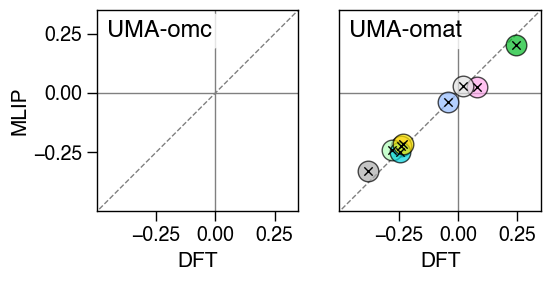

In [240]:

fig, ax = plt.subplots(1,2 , figsize=(6,3), sharey=True)
ax = ax.flatten()
dft = df['DFT'].tolist()
mlips = ['UMA-omc', 'UMA-omat']
lims = [-0.5, 0.35]
plt.rcParams['xtick.major.size'] = 7
ticks = [-0.25, 0, 0.25]
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

for i, mlip in enumerate(mlips):
    mlip_values = df[mlip].tolist()
    ax[i].axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    ax[i].plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax[i].axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    # ax.set_title(mlip)
    ax[i].set_box_aspect(1)
    ax[i].set_xlim(lims)
    ax[i].set_ylim(lims)
    ax[i].set_xticks(ticks)
    ax[i].set_yticks(ticks)
    ax[i].text(0.05, 0.95, mlip, transform=ax[i].transAxes, fontsize=17, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    for j, solute in enumerate(solutes):
        ax[i].scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=2)        
        ax[i].scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=220, edgecolors='k', linewidth=1, alpha=0.7)
    if i == 0:
        ax[i].set_ylabel("MLIP", fontsize=15, labelpad=3)
    else:
        ax[i].get_yaxis().set_visible(False)
    ax[i].set_xlabel("DFT", fontsize=15, labelpad=5)
fig.tight_layout()
plt.savefig('tm/uma.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [243]:
mlip_list

['ompa-mpa',
 'ompa-omat',
 'MACE-mpa',
 'MACE-omat',
 'ORB-mpa',
 'ORB-omat',
 'eSEN-oam',
 'eSEN-omat',
 'DPA-mp',
 'DPA-omat',
 'UMA-omc',
 'UMA-omat',
 'omni-mpa',
 'omni-omat',
 'omni-matpes_pbe']

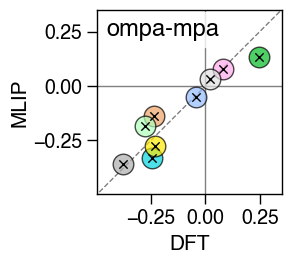

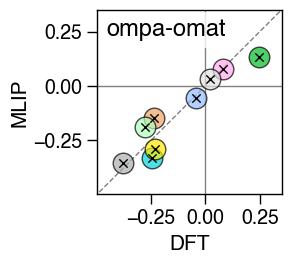

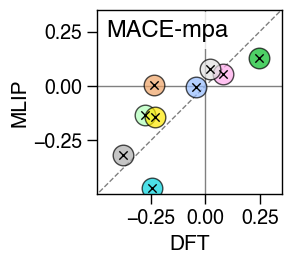

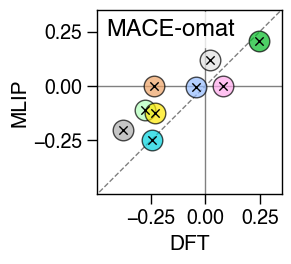

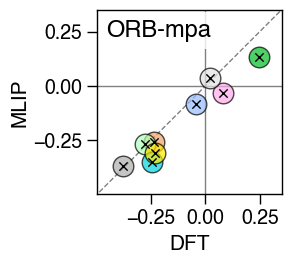

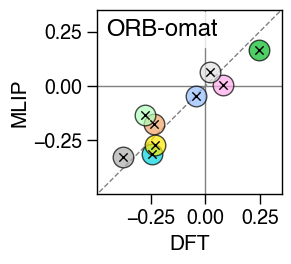

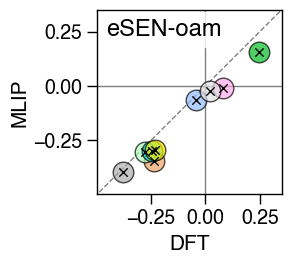

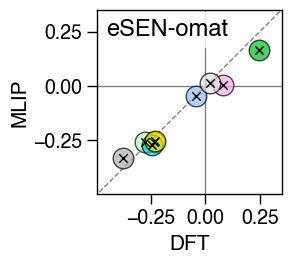

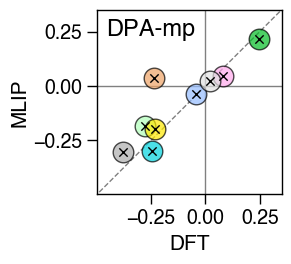

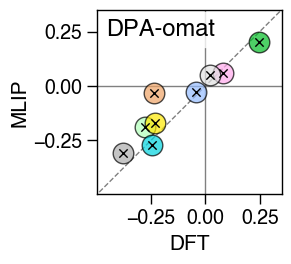

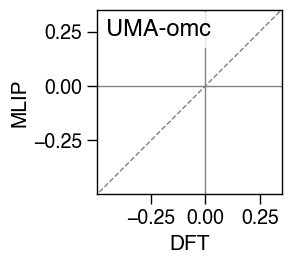

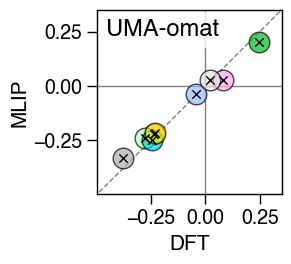

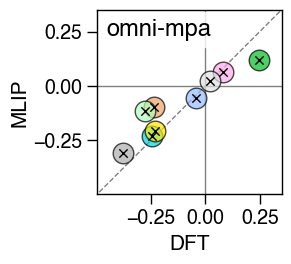

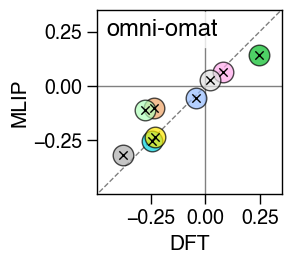

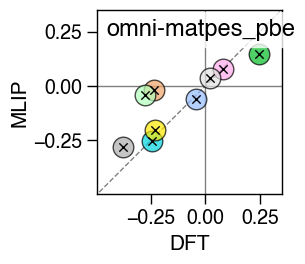

In [244]:


dft = df['DFT'].tolist()
mlips = ['UMA-omat']
lims = [-0.5, 0.35]
plt.rcParams['xtick.major.size'] = 7
ticks = [-0.25, 0, 0.25]
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

for i, mlip in enumerate(mlip_list):
    fig, ax = plt.subplots(figsize=(3,3))
    # ax = ax.flatten()
    mlip_values = df[mlip].tolist()
    ax.axhline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    ax.plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linestyle='-', linewidth=1, zorder=0)
    # ax.set_title(mlip)
    ax.set_box_aspect(1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.text(0.05, 0.95, mlip, transform=ax.transAxes, fontsize=17, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
    for j, solute in enumerate(solutes):
        ax.scatter(dft[j],mlip_values[j], color='k', marker='x', alpha=1, zorder=2)        
        ax.scatter(dft[j], mlip_values[j], color=solute_color_dict[solute], s=220, edgecolors='k', linewidth=1, alpha=0.7)
    ax.set_ylabel("MLIP", fontsize=15, labelpad=3)
    ax.set_xlabel("DFT", fontsize=15, labelpad=5)
    fig.tight_layout()
    plt.savefig(f'tm/{mlip}.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

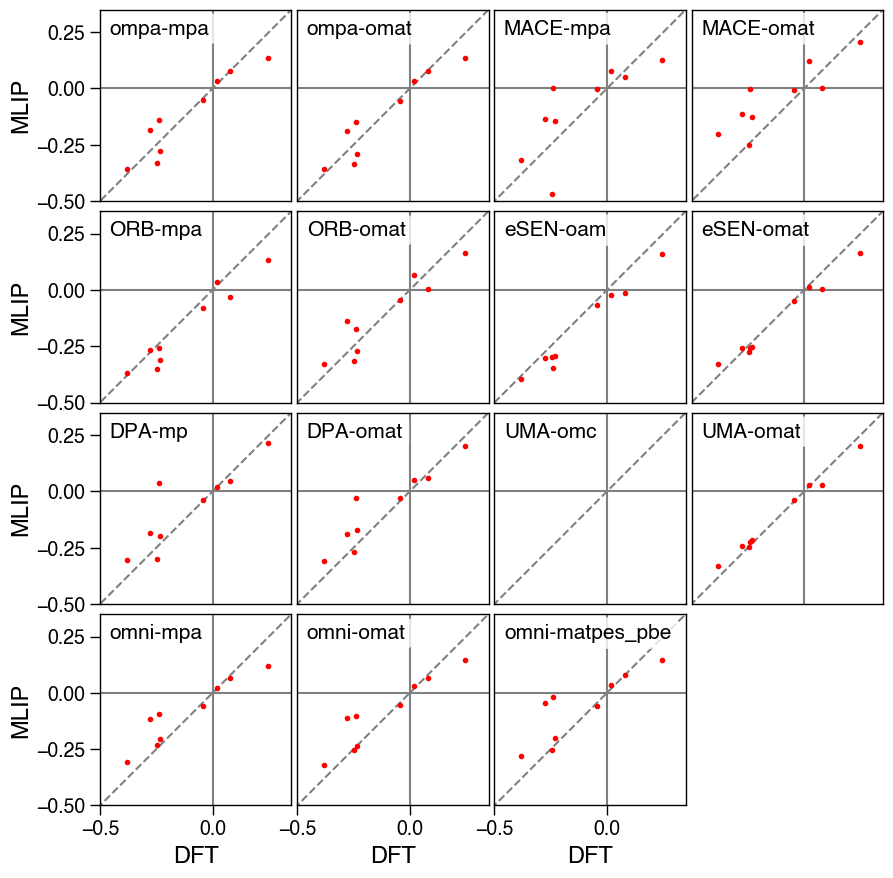

In [246]:
lims = [-0.5, 0.35]
fig, axes = plt.subplots(4,4, figsize=(9,10), sharex=True, sharey=True)
for i, (ax, mlip) in enumerate(zip(axes.flatten(), mlip_list)):
    if i < len(mlip_list):
        ax.plot([-5,5], [-5,5], color='grey', linestyle='--', linewidth=1.5, zorder=0)
        ax.scatter(df['DFT'], df[mlip], color='red', marker='.', alpha=1)
        ax.axhline(0, color='grey', linestyle='-', linewidth=1.5, zorder=0)
        ax.axvline(0, color='grey', linestyle='-', linewidth=1.5, zorder=0)
        # ax.set_title(mlip)
        ax.set_box_aspect(1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.text(0.05, 0.95, mlip, transform=ax.transAxes, fontsize=15, fontweight='bold',verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='none',alpha=0.8))
        if i % 4 == 0:
            ax.set_ylabel("MLIP", fontsize=17, labelpad=3)
        else:
            ax.get_yaxis().set_visible(False)
        if i < 12:
            ax.get_xaxis().set_visible(False)
        else:
            ax.set_xlabel("DFT", fontsize=17, labelpad=5)


        
        # ax.set_xticks(rotation=90)
        # ax.set_ylabel("MLIP")
        # ax.set_xlabel('DFT')
    else:
        # continue
        ax.axis('off')
for ax in axes.flatten()[len(mlip_list):]:
    ax.axis("off")
# fig.tight_layout()

plt.savefig('quick_scatter.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


In [250]:
df_sign = pd.DataFrame(index=df.index)
for mlip in mlip_list:
    cross=df['DFT']*df[mlip]
    df_sign[mlip] = np.sign(cross)
df_sign.to_csv('tm/sign.csv')
df_sign


,ompa-mpa,ompa-omat,MACE-mpa,MACE-omat,ORB-mpa,ORB-omat,eSEN-oam,eSEN-omat,DPA-mp,DPA-omat,UMA-omc,UMA-omat,omni-mpa,omni-omat,omni-matpes_pbe
Co,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0
Cr,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0
Cu,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mn,1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mo,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Nb,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Ni,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Ti,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
V,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
